# Industrial Predictive Maintenance — Classical ML

Complete implementation of the requested workflow:
- Logistic Regression baseline
- Decision Tree
- Random Forest
- Gradient Boosting
- Stratified Train/Test + Cross-Validation
- Class weighting / sample weighting for class imbalance
- Hyperparameter tuning
- Threshold optimization
- Precision / Recall / F1 / PR-AUC / ROC-AUC
- Final trained model saved for Streamlit deployment

The notebook uses a local project CSV when available, otherwise it can download the public UCI AI4I 2020 Predictive Maintenance dataset.


In [1]:
import warnings, io, urllib.request, zipfile
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, average_precision_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay,
    precision_recall_curve
)
from sklearn.utils.class_weight import compute_sample_weight
import joblib

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
np.random.seed(RANDOM_STATE)
print("Libraries loaded.")


Libraries loaded.


In [2]:
# 1) Load the dataset
candidate_paths = [
    Path("ai4i2020.csv"),
    Path("data/ai4i2020.csv"),
    Path("data/AI4I_2020_Predictive_Maintenance_Dataset.csv"),
    Path("../data/ai4i2020.csv"),
]
csv_path = next((p for p in candidate_paths if p.exists()), None)

if csv_path:
    df = pd.read_csv(csv_path)
    print("Loaded local:", csv_path)
else:
    url = "https://archive.ics.uci.edu/static/public/601/ai4i+2020+predictive+maintenance+dataset.zip"
    raw = urllib.request.urlopen(url).read()
    z = zipfile.ZipFile(io.BytesIO(raw))
    csv_name = next(n for n in z.namelist() if n.lower().endswith(".csv"))
    df = pd.read_csv(z.open(csv_name))
    print("Downloaded:", csv_name)

print("Shape:", df.shape)
display(df.head())


Downloaded: ai4i2020.csv
Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
# 2) Cleaning and target setup
df.columns = [c.strip() for c in df.columns]

for col in ["UDI", "Product ID"]:
    if col in df.columns:
        df = df.drop(columns=col)

target = "Machine failure"
if target not in df.columns:
    raise ValueError(f"Target '{target}' not found. Columns: {df.columns.tolist()}")

# These component-specific failure flags directly describe failure events.
# They are removed to avoid target leakage in a deployable pre-failure model.
failure_flags = ["TWF", "HDF", "PWF", "OSF", "RNF"]
df = df.drop(columns=[c for c in failure_flags if c in df.columns])

df[target] = pd.to_numeric(df[target], errors="coerce")
df = df.dropna(subset=[target]).copy()
df[target] = df[target].astype(int)

print("Final shape:", df.shape)
display(df[target].value_counts().rename_axis(target).to_frame("count"))
display((df[target].value_counts(normalize=True)*100).rename_axis(target).to_frame("percent"))


Final shape: (10000, 7)


,count
Machine failure,
0,9661
1,339


,percent
Machine failure,
0,96.61
1,3.39


In [4]:
# 3) Stratified Train/Test split
X = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = [c for c in X_train.columns if c not in categorical_features]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features)
])

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Categorical:", categorical_features)
print("Numeric:", numeric_features)


Train: (8000, 6) Test: (2000, 6)
Categorical: ['Type']
Numeric: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


In [5]:
# 4) Define requested models
models = {
    "Logistic Regression": Pipeline([
        ("prep", preprocessor),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "Decision Tree": Pipeline([
        ("prep", preprocessor),
        ("model", DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestClassifier(
            class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE
        ))
    ]),
    "Gradient Boosting": Pipeline([
        ("prep", preprocessor),
        ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
    ])
}
print(list(models))


['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']


In [6]:
# 5) Baseline: 5-fold Stratified CV
def cv_summary(model, X, y):
    proba = cross_val_predict(
        model, X, y, cv=cv, method="predict_proba", n_jobs=-1
    )[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall": recall_score(y, pred, zero_division=0),
        "F1": f1_score(y, pred, zero_division=0),
        "PR-AUC": average_precision_score(y, proba),
        "ROC-AUC": roc_auc_score(y, proba),
    }

rows = []
for name, model in models.items():
    rows.append({"Model": name, **cv_summary(model, X_train, y_train)})

baseline_results = pd.DataFrame(rows).sort_values("PR-AUC", ascending=False)
display(baseline_results)


,Model,Precision,Recall,F1,PR-AUC,ROC-AUC
3,Gradient Boosting,0.867021,0.601476,0.710240,0.781887,0.971125
2,Random Forest,0.887931,0.380074,0.532300,0.738012,0.961368
0,Logistic Regression,0.137539,0.804428,0.234914,0.432261,0.895408
1,Decision Tree,0.687783,0.560886,0.617886,0.400642,0.775979


In [7]:
# 6) Hyperparameter tuning using PR-AUC
param_grids = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 3, 10, 30],
        "model__solver": ["liblinear", "lbfgs"]
    },
    "Decision Tree": {
        "model__max_depth": [3, 5, 8, 12, None],
        "model__min_samples_split": [2, 5, 10, 20],
        "model__min_samples_leaf": [1, 2, 5, 10],
        "model__criterion": ["gini", "entropy"]
    },
    "Random Forest": {
        "model__n_estimators": [200, 400, 700],
        "model__max_depth": [None, 8, 12, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2"]
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.02, 0.05, 0.1],
        "model__max_depth": [1, 2, 3],
        "model__min_samples_leaf": [1, 3, 5],
        "model__subsample": [0.8, 1.0]
    }
}

tuned = {}
for name, model in models.items():
    search = RandomizedSearchCV(
        model, param_distributions=param_grids[name],
        n_iter=12, scoring="average_precision", cv=cv,
        random_state=RANDOM_STATE, n_jobs=-1, refit=True
    )
    search.fit(X_train, y_train)
    tuned[name] = search.best_estimator_
    print("\n", name)
    print("Best CV PR-AUC:", round(search.best_score_, 5))
    print("Best params:", search.best_params_)



 Logistic Regression
Best CV PR-AUC: 0.44653
Best params: {'model__solver': 'liblinear', 'model__C': 0.1}

 Decision Tree
Best CV PR-AUC: 0.65807
Best params: {'model__min_samples_split': 5, 'model__min_samples_leaf': 10, 'model__max_depth': 12, 'model__criterion': 'entropy'}

 Random Forest
Best CV PR-AUC: 0.76801
Best params: {'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': None}

 Gradient Boosting
Best CV PR-AUC: 0.78698
Best params: {'model__subsample': 0.8, 'model__n_estimators': 300, 'model__min_samples_leaf': 3, 'model__max_depth': 3, 'model__learning_rate': 0.05}


In [8]:
# 7) Class weighting for Gradient Boosting
# GradientBoostingClassifier has no class_weight parameter, so balanced sample weights are used.
gb_weights = compute_sample_weight(class_weight="balanced", y=y_train)

gb_model = tuned["Gradient Boosting"]
gb_model.fit(X_train, y_train, model__sample_weight=gb_weights)
tuned["Gradient Boosting"] = gb_model
print("Gradient Boosting fitted with balanced sample weights.")


Gradient Boosting fitted with balanced sample weights.


In [9]:
# 8) Threshold optimization using out-of-fold probabilities
thresholds = np.linspace(0.05, 0.95, 181)
threshold_info = {}
rows = []

for name, model in tuned.items():
    oof_proba = cross_val_predict(
        model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1
    )[:, 1]
    f1_values = [
        f1_score(y_train, (oof_proba >= t).astype(int), zero_division=0)
        for t in thresholds
    ]
    idx = int(np.argmax(f1_values))
    best_t = float(thresholds[idx])
    threshold_info[name] = {"threshold": best_t, "oof_proba": oof_proba}
    rows.append({
        "Model": name,
        "OOF PR-AUC": average_precision_score(y_train, oof_proba),
        "Optimal Threshold": best_t,
        "OOF F1": f1_values[idx]
    })

threshold_results = pd.DataFrame(rows).sort_values("OOF PR-AUC", ascending=False)
display(threshold_results)


,Model,OOF PR-AUC,Optimal Threshold,OOF F1
3,Gradient Boosting,0.782574,0.295,0.749049
2,Random Forest,0.762755,0.345,0.717949
1,Decision Tree,0.659688,0.950,0.676364
0,Logistic Regression,0.434063,0.890,0.457380


In [10]:
# 9) Fit final candidates and evaluate on untouched test set
def evaluate(model, threshold):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "PR-AUC": average_precision_score(y_test, proba),
        "ROC-AUC": roc_auc_score(y_test, proba),
        "Threshold": threshold
    }

final_rows = []
for name, model in tuned.items():
    if name == "Gradient Boosting":
        model.fit(X_train, y_train, model__sample_weight=gb_weights)
    else:
        model.fit(X_train, y_train)
    final_rows.append({
        "Model": name,
        **evaluate(model, threshold_info[name]["threshold"])
    })

final_results = pd.DataFrame(final_rows).sort_values("PR-AUC", ascending=False)
display(final_results)


,Model,Precision,Recall,F1,PR-AUC,ROC-AUC,Threshold
2,Random Forest,0.742424,0.720588,0.731343,0.792052,0.961195,0.345
1,Decision Tree,0.613636,0.794118,0.692308,0.709993,0.912587,0.950
3,Gradient Boosting,0.291667,0.926471,0.443662,0.708568,0.967939,0.295
0,Logistic Regression,0.450980,0.338235,0.386555,0.381133,0.906612,0.890


Final model: Random Forest
Optimized threshold: 0.3449999999999999

Classification report:
              precision    recall  f1-score   support

           0     0.9902    0.9912    0.9907      1932
           1     0.7424    0.7206    0.7313        68

    accuracy                         0.9820      2000
   macro avg     0.8663    0.8559    0.8610      2000
weighted avg     0.9818    0.9820    0.9819      2000



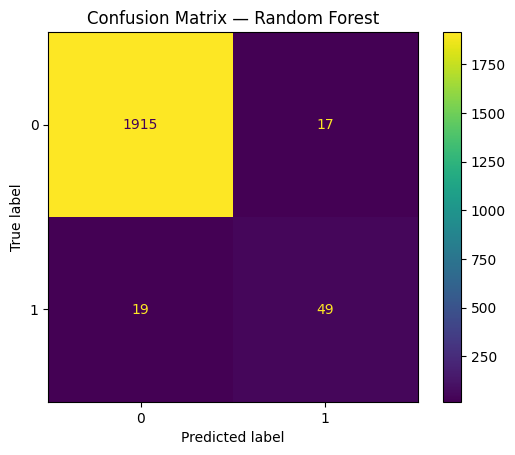

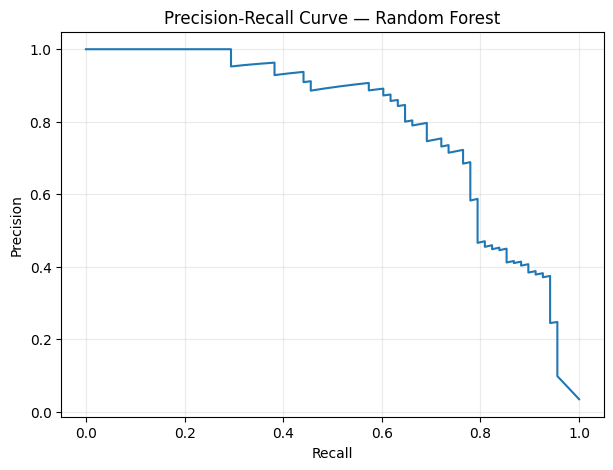

In [11]:
# 10) Final model and detailed test evaluation
selected_name = final_results.iloc[0]["Model"]
selected_model = tuned[selected_name]
selected_threshold = float(final_results.iloc[0]["Threshold"])

test_proba = selected_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= selected_threshold).astype(int)

print("Final model:", selected_name)
print("Optimized threshold:", selected_threshold)
print("\nClassification report:")
print(classification_report(y_test, test_pred, digits=4, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test, test_pred)
plt.title(f"Confusion Matrix — {selected_name}")
plt.show()

precision, recall, _ = precision_recall_curve(y_test, test_proba)
plt.figure(figsize=(7,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve — {selected_name}")
plt.grid(alpha=0.25)
plt.show()


In [12]:
# 11) Save the complete trained pipeline + optimized threshold
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

artifact = {
    "model": selected_model,
    "threshold": selected_threshold,
    "target": target,
    "features": X_train.columns.tolist(),
    "model_name": selected_name,
    "random_state": RANDOM_STATE
}
joblib.dump(artifact, artifacts_dir / "predictive_maintenance_model.joblib")
print("Saved:", artifacts_dir / "predictive_maintenance_model.joblib")


Saved: artifacts\predictive_maintenance_model.joblib


In [13]:
# 12) The notebook can generate these deployment files after the model is trained.
from pathlib import Path
Path("model.py").write_text('from pathlib import Path\nimport joblib\nimport pandas as pd\n\nMODEL_PATH = Path(__file__).resolve().parent / "artifacts" / "predictive_maintenance_model.joblib"\nartifact = joblib.load(MODEL_PATH)\nmodel = artifact["model"]\nthreshold = float(artifact["threshold"])\n\ndef predict(data):\n    if isinstance(data, dict):\n        data = pd.DataFrame([data])\n    elif not isinstance(data, pd.DataFrame):\n        data = pd.DataFrame(data)\n\n    proba = float(model.predict_proba(data)[:, 1][0])\n    prediction = int(proba >= threshold)\n    return {\n        "failure_prediction": prediction,\n        "failure_probability": proba,\n        "threshold": threshold,\n        "status": "Failure Risk" if prediction else "Normal"\n    }\n', encoding="utf-8")
Path("app.py").write_text('import streamlit as st\nfrom model import predict\n\nst.set_page_config(page_title="Industrial Predictive Maintenance", page_icon="🏭")\nst.title("🏭 Industrial Predictive Maintenance")\nst.write("Enter machine sensor readings to estimate failure risk.")\n\nc1, c2 = st.columns(2)\nwith c1:\n    type_ = st.selectbox("Type", ["L", "M", "H"])\n    air_temp = st.number_input("Air temperature [K]", value=300.0)\n    process_temp = st.number_input("Process temperature [K]", value=310.0)\nwith c2:\n    rotational_speed = st.number_input("Rotational speed [rpm]", value=1500.0)\n    torque = st.number_input("Torque [Nm]", value=40.0)\n    tool_wear = st.number_input("Tool wear [min]", value=100.0)\n\nif st.button("Predict"):\n    result = predict({\n        "Type": type_,\n        "Air temperature [K]": air_temp,\n        "Process temperature [K]": process_temp,\n        "Rotational speed [rpm]": rotational_speed,\n        "Torque [Nm]": torque,\n        "Tool wear [min]": tool_wear\n    })\n    st.metric("Failure probability", f"{result[\'failure_probability\']:.2%}")\n    st.write("Optimized threshold:", f"{result[\'threshold\']:.3f}")\n    if result["failure_prediction"]:\n        st.error("⚠️ Failure Risk")\n    else:\n        st.success("✅ Normal")\n', encoding="utf-8")
Path("requirements.txt").write_text(
    "numpy\npandas\nscikit-learn\nmatplotlib\njoblib\nstreamlit\njupyter\n",
    encoding="utf-8"
)
print("Generated model.py, app.py and requirements.txt")


Generated model.py, app.py and requirements.txt


## Streamlit

Execute all notebook cells first so the trained artifact exists:

```bash
pip install -r requirements.txt
jupyter notebook 03_classical_ml.ipynb
```

Then:

```bash
streamlit run app.py
```

The Streamlit app uses the exact preprocessing pipeline, trained classifier and optimized threshold saved by the notebook.
